<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris_WA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [19]:
#All needed imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
from tensorflow.keras.datasets import cifar10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
print("Original training set shape:", x_train_full.shape, y_train_full.shape)
print("Original test set shape:    ", x_test.shape, y_test.shape)

Original training set shape: (50000, 32, 32, 3) (50000, 1)
Original test set shape:     (10000, 32, 32, 3) (10000, 1)


In [8]:
# Normalize the pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [9]:
# Combine train and test to split as 60/20/20
X = np.concatenate([x_train_full, x_test], axis=0)
y = np.concatenate([y_train_full, y_test], axis=0)
print("Full dataset:", X.shape, y.shape)

Full dataset: (60000, 32, 32, 3) (60000, 1)


In [10]:
# Shuffle
np.random.seed(42)
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

In [11]:
# Split the full dateset to: 60% / 20% / 20%
n_total = len(X)  # 60000
n_train = int(0.6 * n_total)  # 36000
n_valid_and_test = int(0.2 * n_total)  # 12000

X_train = X[:n_train]
y_train = y[:n_train]

X_valid = X[n_train:n_train + n_valid_and_test]
y_valid = y[n_train:n_train + n_valid_and_test]

X_test = X[n_train + n_valid_and_test:]
y_test = y[n_train + n_valid_and_test:]

In [12]:
# Print shapes to verify
print("Training set:   ", X_train.shape, y_train.shape)
print("Validation set: ", X_valid.shape, y_valid.shape)
print("Test set:       ", X_test.shape, y_test.shape)

Training set:    (36000, 32, 32, 3) (36000, 1)
Validation set:  (12000, 32, 32, 3) (12000, 1)
Test set:        (12000, 32, 32, 3) (12000, 1)


In [13]:
from tensorflow.keras.utils import to_categorical
num_classes = 10

# Convert to one-hot
y_train_oh = to_categorical(y_train, num_classes)
y_valid_oh   = to_categorical(y_valid, num_classes)
y_test_oh  = to_categorical(y_test, num_classes)

In [14]:
print("y_train one-hot:", y_train_oh.shape)
print("y_val one-hot:", y_valid_oh.shape)
print("y_test one-hot:", y_test_oh.shape)

y_train one-hot: (36000, 10)
y_val one-hot: (12000, 10)
y_test one-hot: (12000, 10)


In [15]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
#first layer
    layers.Conv2D(filters=16, kernel_size=(5, 5), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
#second layer - retain omage size by adding padding zeros
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
#third layer - retain imagr size by adding padding zeros
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

#classification part
    layers.Flatten(),
    layers.Dropout(0.25),

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [27]:
#Create a clone model of the above CNN with exactly the same initial weights.

clone_model = keras.models.clone_model(model)
clone_model.build(input_shape=(None, 32, 32, 3))

# copy same weights
clone_model.set_weights(model.get_weights())

In [28]:
# Early stopping Adam
early_stopping_adam = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [29]:
# Early stopping SGD
early_stopping_sgd = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [21]:
# Compile the original model with Adam
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
# Compile the clone model with SGD
clone_model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# Train model with Adam
history_adam = model.fit(
    X_train, y_train_oh,
    epochs=100,
    validation_data=(X_valid, y_valid_oh),
    callbacks=[early_stopping_adam],
    verbose=1
)

Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.7140 - loss: 0.8077 - val_accuracy: 0.6375 - val_loss: 1.0589
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7169 - loss: 0.7936 - val_accuracy: 0.6418 - val_loss: 1.0471
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7201 - loss: 0.7850 - val_accuracy: 0.6420 - val_loss: 1.0472
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7219 - loss: 0.7781 - val_accuracy: 0.6295 - val_loss: 1.0891
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7272 - loss: 0.7681 - val_accuracy: 0.6408 - val_loss: 1.0647
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7284 - loss: 0.7607 - val_accuracy: 0.6483 - val_loss: 1.0265
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.7347 - loss: 0.7466 - val_accuracy: 0.6466 - val_loss: 1.0491
Epoch 8/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 

In [31]:
# Train model with SGD
history_sgd = clone_model.fit(
    X_train, y_train_oh,
    epochs=100,
    validation_data=(X_valid, y_valid_oh),
    callbacks=[early_stopping_sgd],
    verbose=1
)

Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.7126 - loss: 0.8073 - val_accuracy: 0.6482 - val_loss: 1.0287
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7175 - loss: 0.7939 - val_accuracy: 0.6503 - val_loss: 1.0280
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7199 - loss: 0.7847 - val_accuracy: 0.6332 - val_loss: 1.0764
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7214 - loss: 0.7756 - val_accuracy: 0.6317 - val_loss: 1.0918
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7283 - loss: 0.7578 - val_accuracy: 0.6515 - val_loss: 1.0385
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7297 - loss: 0.7547 - val_accuracy: 0.6463 - val_loss: 1.0467
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7332 - loss: 0.7476 - val_accuracy: 0.6437 - val_loss: 1.0667


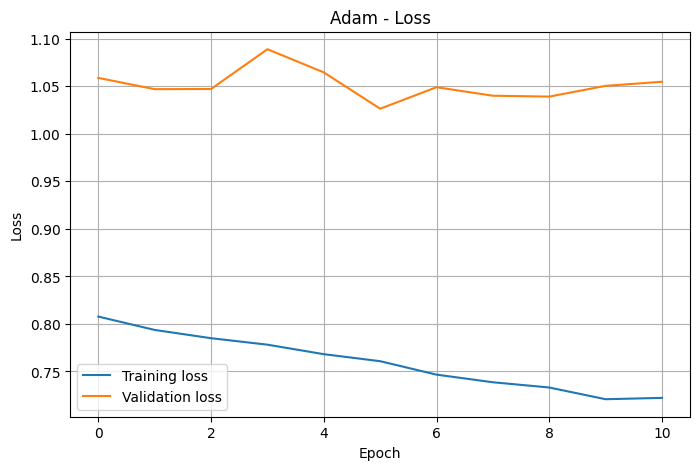

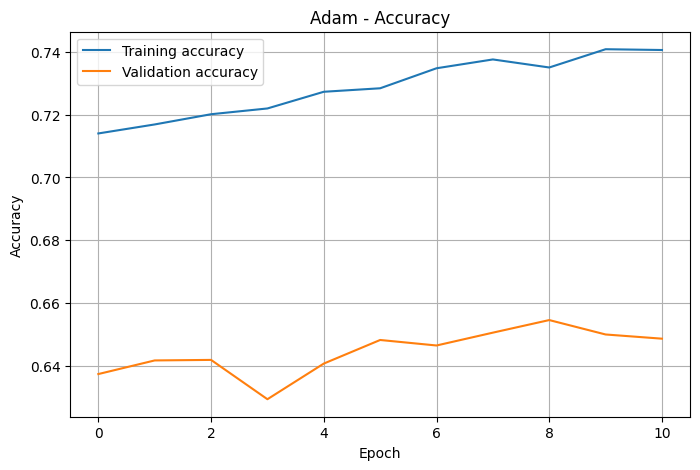

In [33]:
# Adam
plt.figure(figsize=(8, 5))
plt.plot(history_adam.history["loss"], label="Training loss")
plt.plot(history_adam.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_adam.history["accuracy"], label="Training accuracy")
plt.plot(history_adam.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam - Accuracy")
plt.legend()
plt.grid(True)
plt.show()



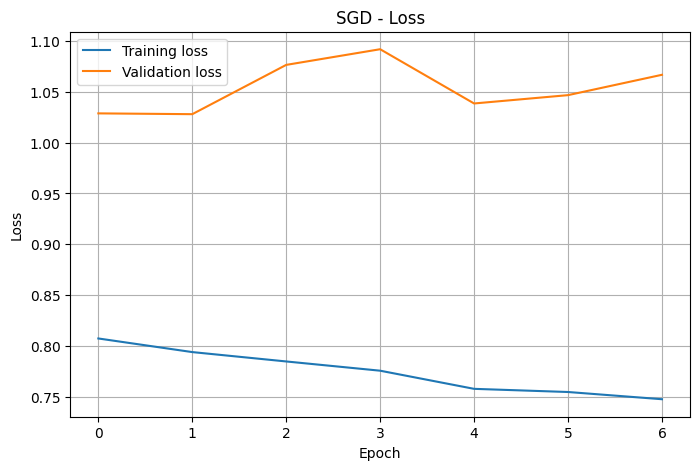

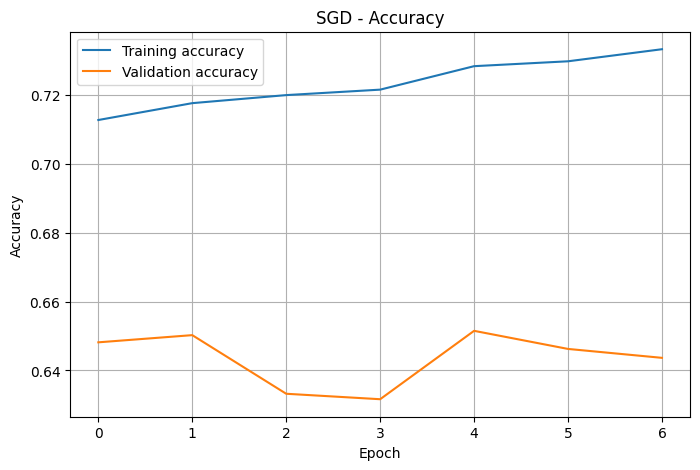

In [34]:
# SGD
plt.figure(figsize=(8, 5))
plt.plot(history_sgd.history["loss"], label="Training loss")
plt.plot(history_sgd.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_sgd.history["accuracy"], label="Training accuracy")
plt.plot(history_sgd.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SGD - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Both Adam and SGD successfully learn the task, as training loss decreases and accuracy increases. Adam converges faster and reaches good performance in fewer epochs, while SGD improves more slowly. In both cases, validation performance stabilizes around 65% and then slightly deteriorates, indicating mild overfitting. Early stopping prevents further overfitting. Overall, both optimizers achieve similar final performance, but Adam is more efficient.

In [35]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_oh, verbose=0)
print("Test accuracy:", test_accuracy)

Test accuracy: 0.6527500152587891


In [36]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [37]:
y_true = y_test.flatten()  # convert from (n,1) to (n,)

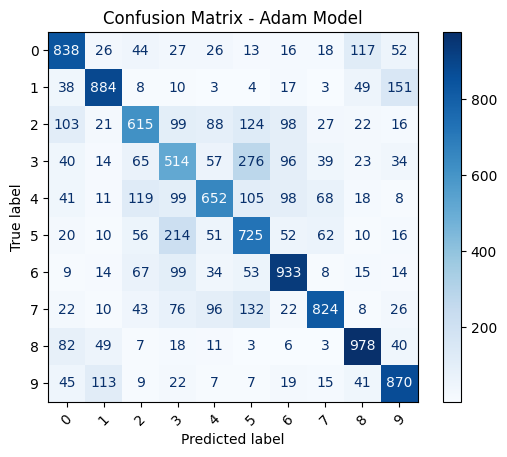

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Adam Model")
plt.show()